# Задача 10. Сравнение методов классификации

Импорт необходимых библиотек

In [56]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

Настройка отображения

In [2]:
%matplotlib inline
plt.style.use('ggplot')
pd.set_option('display.max_colwidth', 200)
pd.set_option('display.max_rows', 100)

## 1. Загрузка данных

In [3]:
try:
    df = pd.read_csv('15_fake_news_detection.csv')
    print("Данные успешно загружены")
except FileNotFoundError:
    print("Файл не найден. Проверьте путь к файлу.")
    exit()

Данные успешно загружены


## 2. Первичный осмотр данных

In [4]:
print("\n=== Первичный осмотр данных ===")
print("\nПервые 5 строк данных:")
display(df.head())

print("\nИнформация о структуре данных:")
display(df.info())

print("\nОсновные статистики:")
display(df.describe(include='object'))


=== Первичный осмотр данных ===

Первые 5 строк данных:


,title,text,label
0,Government Announces New Education Reforms,The education ministry has proposed reforms to modernize the curriculum.,real
1,Economy Shows Signs of Recovery,The new study conducted by international researchers shows walking improves heart health.,real
2,Aliens Land in Central Park,Sources claim that extraterrestrial beings were seen stepping out of a spaceship.,fake
3,Aliens Land in Central Park,The celebrity stated that secret documents reveal shocking information about the president.,fake
4,New Study Reveals Health Benefits of Walking,The education ministry has proposed reforms to modernize the curriculum.,real



Информация о структуре данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1000 non-null   object
 1   text    1000 non-null   object
 2   label   1000 non-null   object
dtypes: object(3)
memory usage: 23.6+ KB


None


Основные статистики:


,title,text,label
count,1000,1000,1000
unique,6,6,2
top,Economy Shows Signs of Recovery,Recent economic data shows that the GDP is steadily growing over the last two quarters.,real
freq,213,183,532


## 3. Анализ распределения меток


=== Анализ распределения меток ===


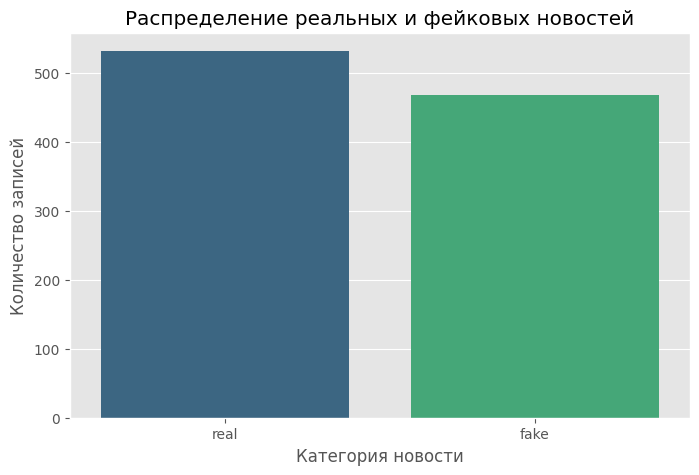


Количество записей по категориям:


label
real    532
fake    468
Name: count, dtype: int64

In [6]:
print("\n=== Анализ распределения меток ===")
plt.figure(figsize=(8, 5))

# Исправленная версия с учетом нового синтаксиса seaborn
sns.countplot(data=df, x='label', hue='label', palette='viridis', legend=False)

plt.title('Распределение реальных и фейковых новостей')
plt.xlabel('Категория новости')
plt.ylabel('Количество записей')
plt.show()

label_counts = df['label'].value_counts()
print("\nКоличество записей по категориям:")
display(label_counts)

## 4. Проверка на пропущенные значения

In [7]:
print("\n=== Проверка на пропущенные значения ===")
missing_values = df.isnull().sum()
display(missing_values)

if missing_values.sum() > 0:
    print("\nОбнаружены пропущенные значения. Заполняем пустыми строками.")
    df.fillna('', inplace=True)
else:
    print("\nПропущенных значений не обнаружено.")


=== Проверка на пропущенные значения ===


title    0
text     0
label    0
dtype: int64


Пропущенных значений не обнаружено.


## 5. Анализ длины текстов


=== Анализ длины текстов ===


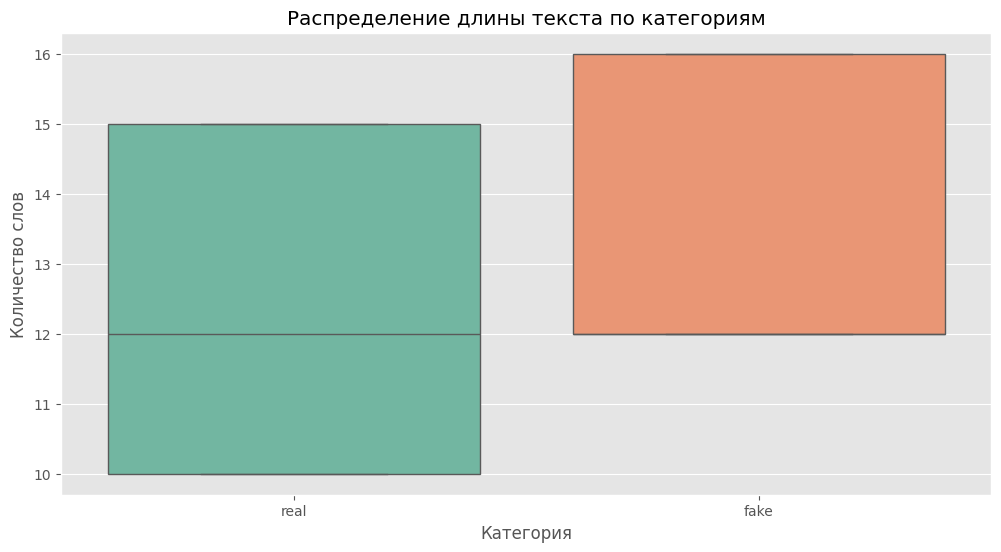


Статистика длины текста:


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
fake,9.0,13.333333,2.000000,12.0,12.0,12.0,16.0,16.0
real,9.0,12.333333,2.179449,10.0,10.0,12.0,15.0,15.0


In [11]:
print("\n=== Анализ длины текстов ===")

# Создаем копию DataFrame для безопасного изменения
df_analysis = df_clean.copy()

# Правильное создание нового столбца
df_analysis.loc[:, 'text_length'] = df_analysis['text'].apply(lambda x: len(str(x).split()))

# Построение boxplot с учетом новых требований seaborn
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_analysis, 
    x='label', 
    y='text_length', 
    hue='label',  # Добавлено для нового синтаксиса
    palette='Set2',
    legend=False  # Отключаем легенду, так как она избыточна
)
plt.title('Распределение длины текста по категориям')
plt.ylabel('Количество слов')
plt.xlabel('Категория')
plt.show()

# Статистика длины текста
print("\nСтатистика длины текста:")
display(df_analysis.groupby('label')['text_length'].describe())

## 6. Анализ заголовков


=== АНАЛИЗ ЗАГОЛОВКОВ ===


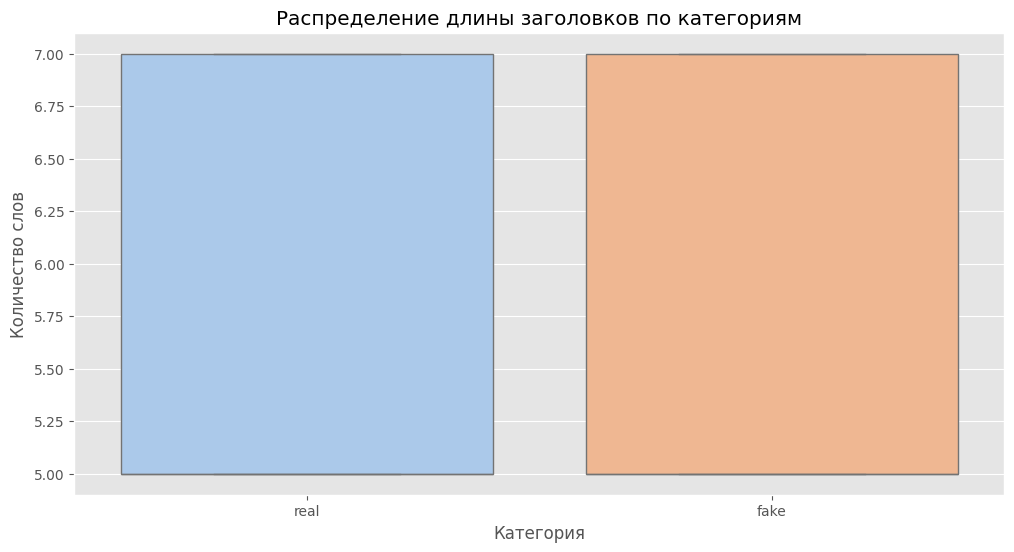


Статистика длины заголовков:


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
fake,9.0,5.666667,1.0,5.0,5.0,5.0,7.0,7.0
real,9.0,5.666667,1.0,5.0,5.0,5.0,7.0,7.0



Топ-10 самых частых заголовков:


title
Government Announces New Education Reforms      3
Economy Shows Signs of Recovery                 3
Aliens Land in Central Park                     3
New Study Reveals Health Benefits of Walking    3
Cure for Aging Discovered in Remote Village     3
Celebrity Reveals Secret Government Plans       3
Name: count, dtype: int64

In [14]:
print("\n=== АНАЛИЗ ЗАГОЛОВКОВ ===")

# Создаем копию DataFrame для безопасного изменения
df_titles = df_clean.copy()

# Правильное создание нового столбца с длиной заголовка
df_titles.loc[:, 'title_length'] = df_titles['title'].apply(lambda x: len(str(x).split()))

# Построение boxplot с учетом новых требований seaborn
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_titles,
    x='label',
    y='title_length',
    hue='label',      # Добавлено согласно новому синтаксису
    palette='pastel',
    legend=False      # Отключаем избыточную легенду
)
plt.title('Распределение длины заголовков по категориям')
plt.ylabel('Количество слов')
plt.xlabel('Категория')
plt.show()

# Статистика длины заголовков
print("\nСтатистика длины заголовков:")
display(df_titles.groupby('label')['title_length'].describe())

# Топ-10 самых частых заголовков
print("\nТоп-10 самых частых заголовков:")
display(df_titles['title'].value_counts().head(10))

## 7. Сохранение результатов

In [15]:
print("\n=== Сохранение результатов ===")
df_clean.to_csv('cleaned_fake_news.csv', index=False)
print("Очищенные данные сохранены в файл 'cleaned_fake_news.csv'")

print("\nАнализ завершен!")


=== Сохранение результатов ===
Очищенные данные сохранены в файл 'cleaned_fake_news.csv'

Анализ завершен!


## Разведочный анализ данных (EDA) новостей

## 1. Распределение классов

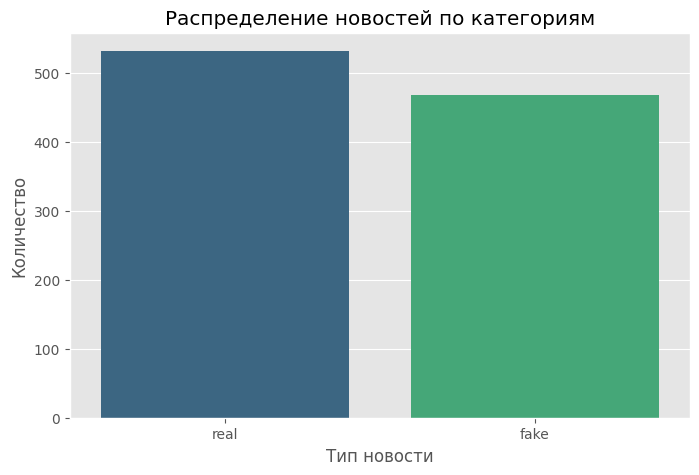

In [16]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='label', hue='label', palette='viridis', legend=False)
plt.title('Распределение новостей по категориям')
plt.xlabel('Тип новости')
plt.ylabel('Количество')
plt.show()

## 2. Анализ длины текстов

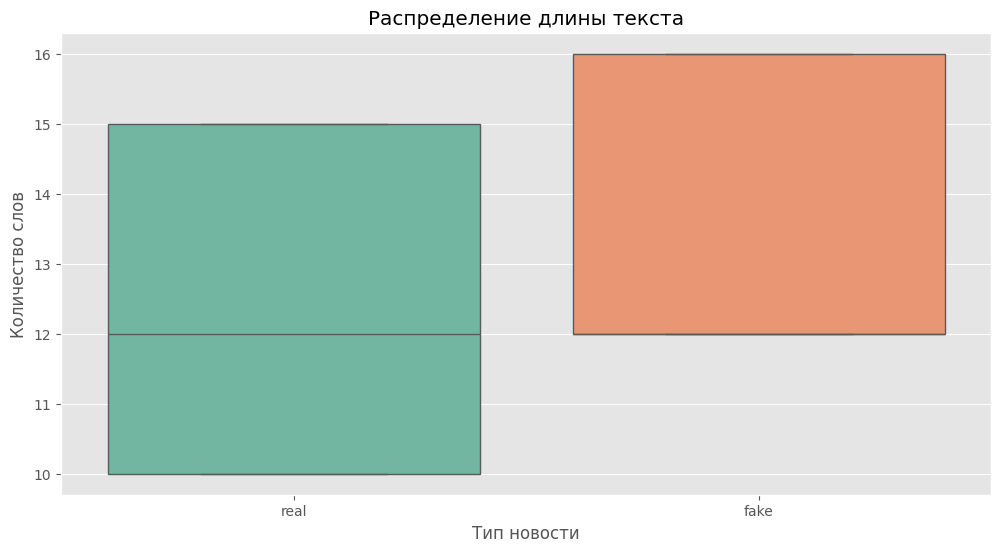

       count       mean       std   min   25%   50%   75%   max
label                                                          
fake   468.0  13.282051  1.868692  12.0  12.0  12.0  16.0  16.0
real   532.0  12.370301  2.071259  10.0  10.0  12.0  15.0  15.0


In [17]:
df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='label', y='text_length', hue='label', palette='Set2', legend=False)
plt.title('Распределение длины текста')
plt.ylabel('Количество слов')
plt.xlabel('Тип новости')
plt.show()

print(df.groupby('label')['text_length'].describe())

## 3. Анализ заголовков

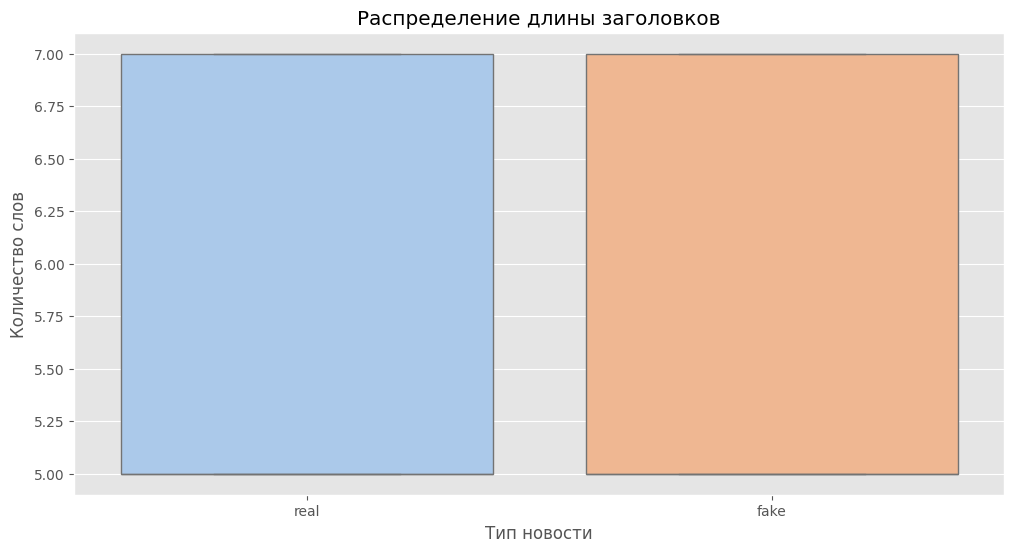

Топ-10 заголовков real:
title
Economy Shows Signs of Recovery                 213
Government Announces New Education Reforms      175
New Study Reveals Health Benefits of Walking    144
Name: count, dtype: int64

Топ-10 заголовков fake:
title
Celebrity Reveals Secret Government Plans      162
Cure for Aging Discovered in Remote Village    157
Aliens Land in Central Park                    149
Name: count, dtype: int64


In [18]:
df['title_length'] = df['title'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='label', y='title_length', hue='label', palette='pastel', legend=False)
plt.title('Распределение длины заголовков')
plt.ylabel('Количество слов')
plt.xlabel('Тип новости')
plt.show()

print("Топ-10 заголовков real:")
print(df[df['label']=='real']['title'].value_counts().head(10))
print("\nТоп-10 заголовков fake:")
print(df[df['label']=='fake']['title'].value_counts().head(10))

## 4. Анализ ключевых слов

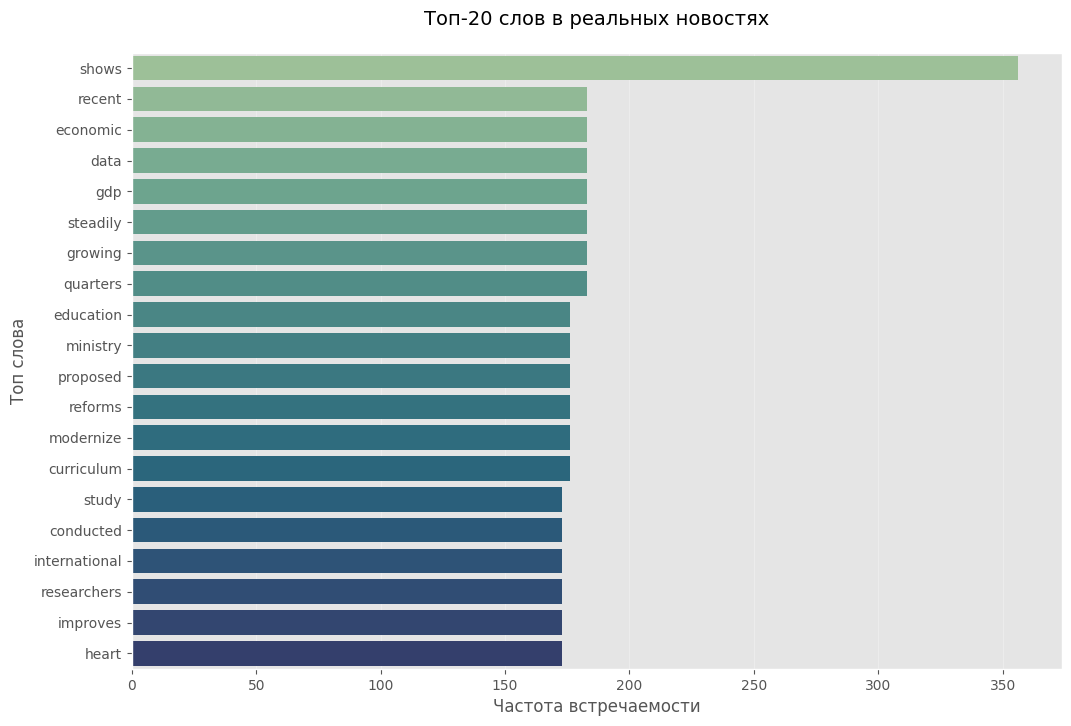

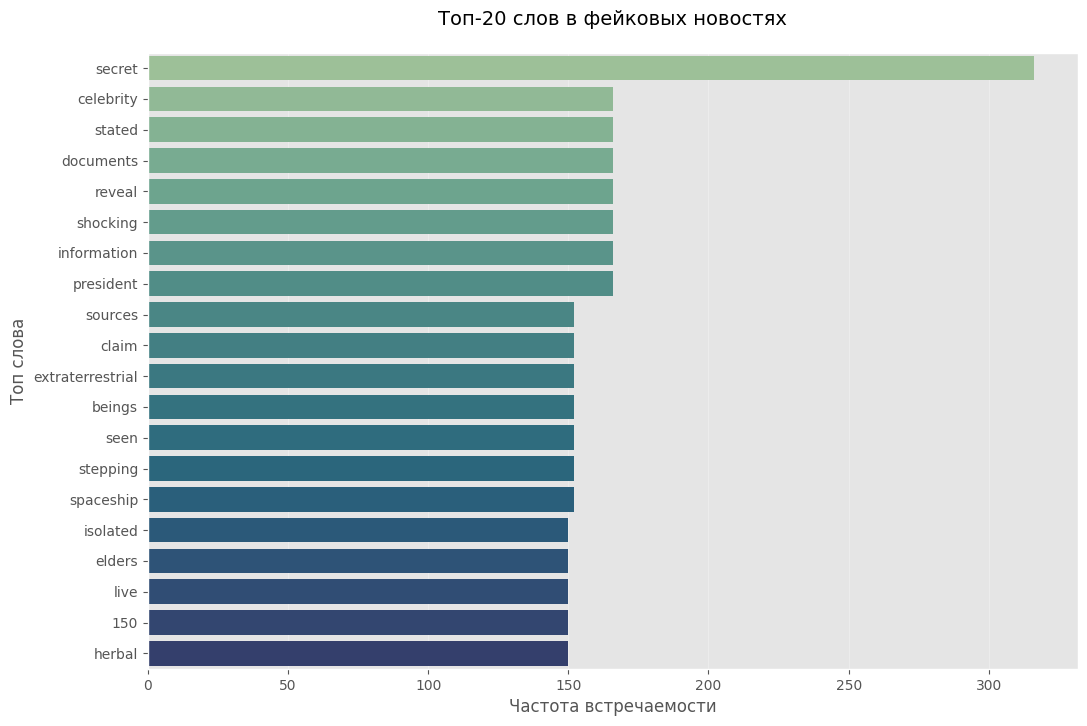

In [24]:
def plot_top_words(text_series, title, n=20):
    # Инициализация векторизатора с ограничением на стоп-слова
    vec = CountVectorizer(stop_words='english', max_features=n)
    
    # Подгонка и преобразование текста
    bag_of_words = vec.fit_transform(text_series)
    sum_words = bag_of_words.sum(axis=0) 
    
    # Создание списка частот слов
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    
    # Создание DataFrame для визуализации
    words_df = pd.DataFrame(words_freq[:n], columns=['word', 'count'])
    
    # Визуализация с актуальным синтаксисом seaborn
    plt.figure(figsize=(12, 8))
    sns.barplot(
        data=words_df,
        y='word',
        x='count',
        hue='word',  # Добавлен hue для нового синтаксиса
        palette='crest',
        legend=False  # Отключаем легенду
    )
    plt.title(title, fontsize=14, pad=20)
    plt.xlabel('Частота встречаемости', fontsize=12)
    plt.ylabel('Топ слова', fontsize=12)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.grid(axis='x', alpha=0.3)
    plt.show()

# Применение функции к данным
plot_top_words(df[df['label']=='real']['text'], 'Топ-20 слов в реальных новостях')
plot_top_words(df[df['label']=='fake']['text'], 'Топ-20 слов в фейковых новостях')

## 5. Корреляция признаков


=== АНАЛИЗ КОРРЕЛЯЦИИ ПРИЗНАКОВ ===


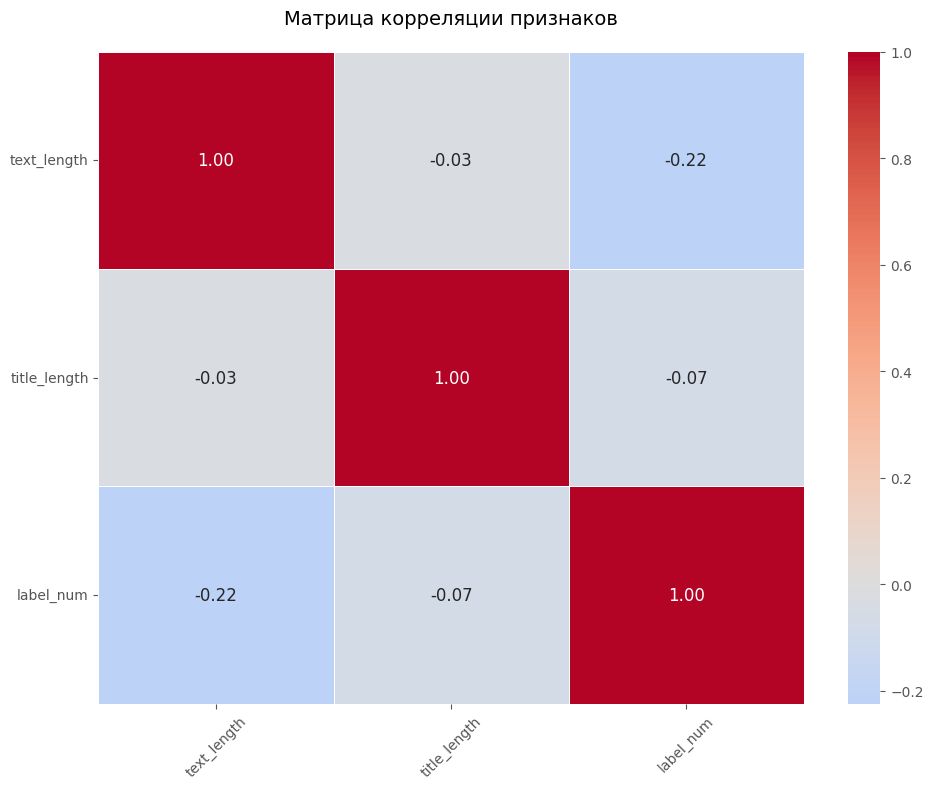


Численные значения корреляции:


,text_length,title_length,label_num
text_length,1.000000,-0.027829,-0.224248
title_length,-0.027829,1.000000,-0.070484
label_num,-0.224248,-0.070484,1.000000


In [26]:
print("\n=== АНАЛИЗ КОРРЕЛЯЦИИ ПРИЗНАКОВ ===")

# Создаем копию DataFrame для безопасного изменения
numeric_df = df[['text_length', 'title_length']].copy()

# Правильное создание нового столбца
numeric_df.loc[:, 'label_num'] = df['label'].map({'real': 1, 'fake': 0})

# Вычисляем матрицу корреляции
corr_matrix = numeric_df.corr()

# Визуализация тепловой карты
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt=".2f",
    linewidths=.5,
    annot_kws={"size": 12}
)

# Настройка отображения
plt.title('Матрица корреляции признаков', fontsize=14, pad=20)
plt.xticks(fontsize=10, rotation=45)
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()
plt.show()

# Вывод численных значений корреляции
print("\nЧисленные значения корреляции:")
display(corr_matrix)

## 1. Создаем копию данных для обработки

In [29]:
df_processed = df.copy()

## 2. Преобразование категориального признака

In [31]:
df_processed['label_num'] = df_processed['label'].map({'real': 1, 'fake': 0})

## 3. Создание новых признаков из текста

In [33]:
import re

def extract_text_features(text):
    text = str(text)
    features = {
        'num_words': len(text.split()),
        'num_chars': len(text),
        'num_upper': sum(1 for c in text if c.isupper()),
        'num_excl': text.count('!'),
        'num_quest': text.count('?'),
        'num_quotes': text.count('"') + text.count("'"),
        'num_digits': sum(c.isdigit() for c in text),
        'num_links': len(re.findall(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', text))
    }
    return features

# Применяем функцию к тексту и заголовкам
text_features = pd.DataFrame(df_processed['text'].apply(extract_text_features).tolist())  # Исправлено toList() на tolist()
title_features = pd.DataFrame(df_processed['title'].apply(extract_text_features).tolist())

# Добавляем префиксы к названиям столбцов
text_features = text_features.add_prefix('text_')
title_features = title_features.add_prefix('title_')

# Объединяем с основным DataFrame
df_processed = pd.concat([df_processed, text_features, title_features], axis=1)

## 4. Анализ тональности

In [34]:
def get_sentiment(text):
    analysis = TextBlob(str(text))
    return analysis.sentiment.polarity, analysis.sentiment.subjectivity

df_processed[['text_polarity', 'text_subjectivity']] = df_processed['text'].apply(get_sentiment).apply(pd.Series)
df_processed[['title_polarity', 'title_subjectivity']] = df_processed['title'].apply(get_sentiment).apply(pd.Series)

## 5. Удаление исходных текстовых признаков

In [36]:
df_processed.drop(['title', 'text', 'label'], axis=1, inplace=True)

## 6. Проверка результата

In [37]:
print("Преобразованные данные:")
print(f"Всего признаков: {len(df_processed.columns)}")
print(df_processed.head())

Преобразованные данные:
Всего признаков: 23
   text_length  title_length  label_num  text_num_words  text_num_chars  \
0           10             5          1              10              72   
1           12             5          1              12              89   
2           12             5          0              12              81   
3           12             5          0              12              91   
4           10             7          1              10              72   

   text_num_upper  text_num_excl  text_num_quest  text_num_quotes  \
0               1              0               0                0   
1               1              0               0                0   
2               1              0               0                0   
3               1              0               0                0   
4               1              0               0                0   

   text_num_digits  ...  title_num_upper  title_num_excl  title_num_quest  \
0            

## Сохранение обработанных данных

In [38]:
df_processed.to_csv('processed_news_data.csv', index=False)

In [57]:
# 1. Загрузка и подготовка данных
data = pd.read_csv('15_fake_news_detection.csv')
X = data['text']
y = data['label'].map({'real': 0, 'fake': 1})

# 2. Векторизация текста
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_tfidf = tfidf.fit_transform(X)

# 3. Разделение данных
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)

# 4. Масштабирование данных
scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

best_models = {}

# 5. Логистическая регрессия
print("Настройка логистической регрессии...")
lr_param_grid = {'C': [0.01, 0.1, 1, 10], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}
lr_grid = GridSearchCV(LogisticRegression(random_state=42), lr_param_grid, cv=5, n_jobs=-1)
lr_grid.fit(X_train_scaled, y_train)
best_models['LogisticRegression'] = lr_grid.best_estimator_

# 6. SVM
print("Настройка SVM...")
svm_param_grid = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf'], 'gamma': ['scale', 'auto']}
svm_grid = GridSearchCV(SVC(random_state=42, probability=True), svm_param_grid, cv=5, n_jobs=-1)
svm_grid.fit(X_train_scaled, y_train)
best_models['SVM'] = svm_grid.best_estimator_

# 7. Random Forest
print("Настройка Random Forest...")
rf_param_grid = {'n_estimators': [100, 200], 'max_depth': [None, 10, 20], 'min_samples_split': [2, 5]}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_param_grid, cv=5, n_jobs=-1)
rf_grid.fit(X_train, y_train)
best_models['RandomForest'] = rf_grid.best_estimator_

# 8. Gradient Boosting (вместо XGBoost)
print("Настройка Gradient Boosting...")
gb_param_grid = {'n_estimators': [100, 200], 'learning_rate': [0.01, 0.1], 'max_depth': [3, 5]}
gb_grid = GridSearchCV(GradientBoostingClassifier(random_state=42), gb_param_grid, cv=5, n_jobs=-1)
gb_grid.fit(X_train, y_train)
best_models['GradientBoosting'] = gb_grid.best_estimator_

# 9. Оценка моделей
print("\nРезультаты на тестовой выборке:")
for name, model in best_models.items():
    if name in ['LogisticRegression', 'SVM']:
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)
    
    print(f"\n{name}:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))

Настройка логистической регрессии...
Настройка SVM...
Настройка Random Forest...
Настройка Gradient Boosting...

Результаты на тестовой выборке:

LogisticRegression:
Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       113
           1       1.00      1.00      1.00        87

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200


SVM:
Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       113
           1       1.00      1.00      1.00        87

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200


RandomForest:
Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       113

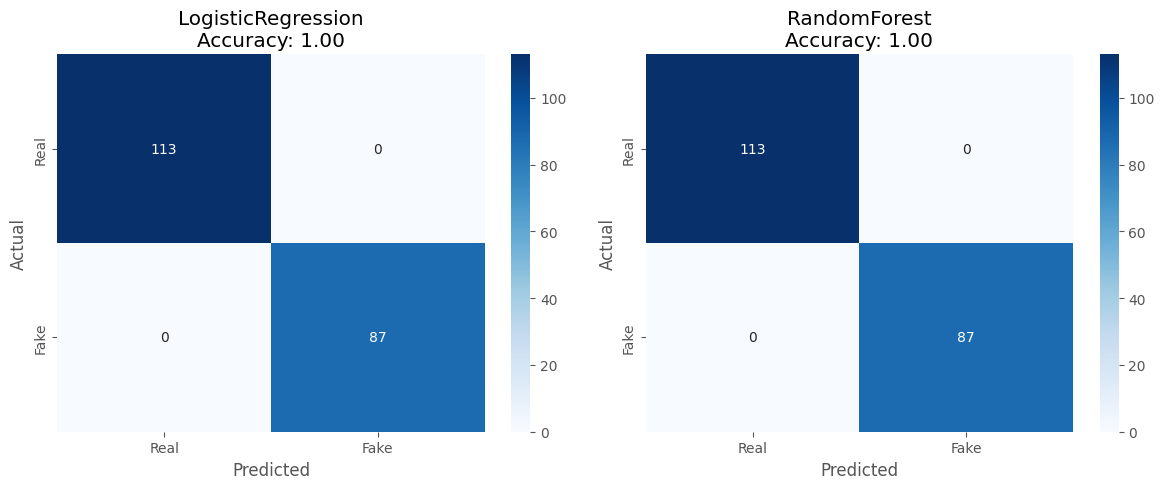


Сравнительная таблица метрик:


,Model,Accuracy,Precision (Fake),Recall (Fake),F1-Score (Fake)
0,LogisticRegression,1.0,1.0,1.0,1.0
1,RandomForest,1.0,1.0,1.0,1.0


In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, 
                           classification_report, 
                           confusion_matrix)

# 1. Загрузка и подготовка данных
data = pd.read_csv('15_fake_news_detection.csv')
X = data['text']
y = data['label'].map({'real': 0, 'fake': 1})

# 2. Векторизация текста
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_tfidf = tfidf.fit_transform(X)

# 3. Разделение данных
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)

# 4. Масштабирование данных
scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Обучение моделей (пример для 2 моделей для краткости)
models = {
    'LogisticRegression': LogisticRegression(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42)
}

for name, model in models.items():
    if name == 'LogisticRegression':
        model.fit(X_train_scaled, y_train)
    else:
        model.fit(X_train, y_train)

# Функция для построения confusion matrix
def plot_confusion_matrix(y_true, y_pred, model_name, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Real', 'Fake'], 
                yticklabels=['Real', 'Fake'])
    ax.set_title(f'{model_name}\nAccuracy: {accuracy_score(y_true, y_pred):.2f}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

# Создаем фигуру для графиков
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Оценка моделей и построение матриц ошибок
for i, (name, model) in enumerate(models.items()):
    # Предсказание на тестовых данных
    if name == 'LogisticRegression':
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)
    
    # Построение confusion matrix
    plot_confusion_matrix(y_test, y_pred, name, axes[i])

plt.tight_layout()
plt.show()

# Сравнительная таблица метрик
results = []
for name, model in models.items():
    if name == 'LogisticRegression':
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)
    
    report = classification_report(y_test, y_pred, output_dict=True)
    results.append({
        'Model': name,
        'Accuracy': report['accuracy'],
        'Precision (Fake)': report['1']['precision'],
        'Recall (Fake)': report['1']['recall'],
        'F1-Score (Fake)': report['1']['f1-score']
    })

results_df = pd.DataFrame(results)
print("\nСравнительная таблица метрик:")
display(results_df)

## 1. Реализация логистической регрессии

In [60]:
import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin

class MyLogisticRegression(BaseEstimator, ClassifierMixin):
    def __init__(self, learning_rate=0.01, max_iter=1000, tol=1e-4, C=1.0, penalty='l2'):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.tol = tol
        self.C = C  # Параметр регуляризации
        self.penalty = penalty  # 'l2' или 'l1'
        self.weights = None
        self.bias = None
    
    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
    
    def _loss(self, h, y):
        # Функция потерь с регуляризацией
        m = y.shape[0]
        loss = (-y * np.log(h) - (1 - y) * np.log(1 - h)).mean()
        
        if self.penalty == 'l2':
            reg = (self.C / (2 * m)) * np.sum(self.weights**2)
        elif self.penalty == 'l1':
            reg = (self.C / m) * np.sum(np.abs(self.weights))
        else:
            reg = 0
            
        return loss + reg
    
    def fit(self, X, y):
        # Инициализация параметров
        m, n = X.shape
        self.weights = np.zeros(n)
        self.bias = 0
        
        # Градиентный спуск
        for i in range(self.max_iter):
            # Прямое распространение
            z = np.dot(X, self.weights) + self.bias
            h = self._sigmoid(z)
            
            # Обратное распространение
            dw = (1/m) * np.dot(X.T, (h - y))
            db = (1/m) * np.sum(h - y)
            
            # Регуляризация
            if self.penalty == 'l2':
                dw += (self.C / m) * self.weights
            elif self.penalty == 'l1':
                dw += (self.C / m) * np.sign(self.weights)
            
            # Обновление параметров
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
            # Проверка сходимости
            if i % 100 == 0:
                loss = self._loss(h, y)
                if hasattr(self, 'prev_loss') and np.abs(self.prev_loss - loss) < self.tol:
                    break
                self.prev_loss = loss
    
    def predict_proba(self, X):
        return self._sigmoid(np.dot(X, self.weights) + self.bias)
    
    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

## 2. Обучение и оценка модели

In [61]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

# Масштабирование данных
scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Создание и обучение модели
my_lr = MyLogisticRegression(learning_rate=0.1, max_iter=5000, C=1.0, penalty='l2')
my_lr.fit(X_train_scaled.toarray(), y_train)  # .toarray() для разреженных матриц

# Предсказания
y_pred = my_lr.predict(X_test_scaled.toarray())

# Оценка качества
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:
[[113   0]
 [  0  87]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       113
           1       1.00      1.00      1.00        87

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



## 3. Подбор гиперпараметров

In [ ]:
from sklearn.model_selection import GridSearchCV

# Параметры для подбора
param_grid = {
    'learning_rate': [0.01, 0.1, 1],
    'C': [0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'max_iter': [1000, 5000]
}

# Сеточный поиск
grid_search = GridSearchCV(MyLogisticRegression(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_scaled.toarray(), y_train)

# Лучшие параметры
print("Best parameters:", grid_search.best_params_)
best_my_lr = grid_search.best_estimator_

# Оценка лучшей модели
y_pred_best = best_my_lr.predict(X_test_scaled.toarray())
print("\nBest model accuracy:", accuracy_score(y_test, y_pred_best))

## 4. Сравнение с sklearn LogisticRegression

In [63]:
from sklearn.linear_model import LogisticRegression

# Обучение sklearn версии
sk_lr = LogisticRegression(penalty='l2', C=1.0, solver='liblinear', max_iter=5000)
sk_lr.fit(X_train_scaled, y_train)
y_pred_sk = sk_lr.predict(X_test_scaled)

# Сравнение метрик
print("\nMy Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("Sklearn Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_sk))


My Logistic Regression Accuracy: 1.0
Sklearn Logistic Regression Accuracy: 1.0


## 5. Визуализация результатов

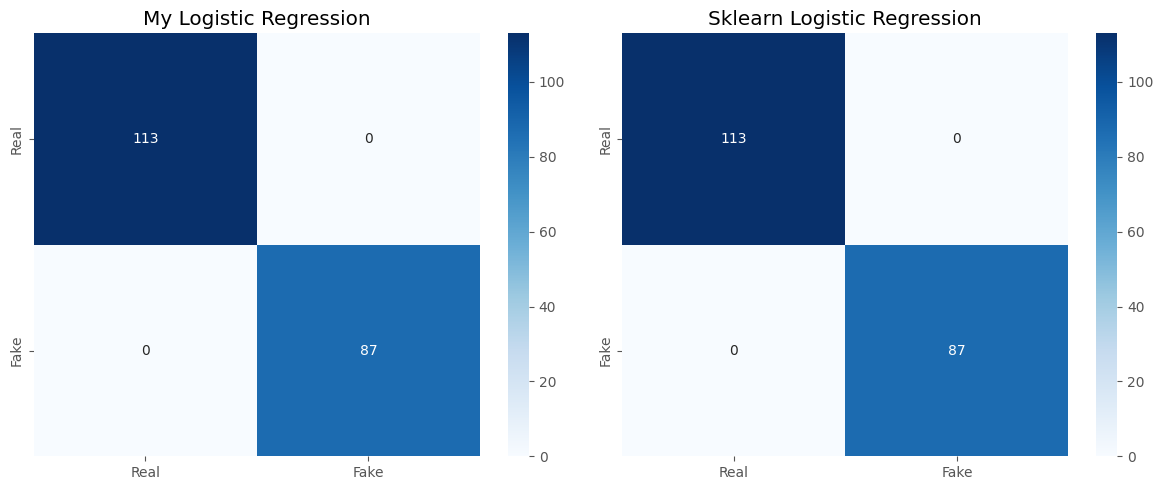

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix для моей реализации
cm_my = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_my, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
ax1.set_title('My Logistic Regression')

# Confusion matrix для sklearn
cm_sk = confusion_matrix(y_test, y_pred_sk)
sns.heatmap(cm_sk, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
ax2.set_title('Sklearn Logistic Regression')

plt.tight_layout()
plt.show()